In [ ]:
import os
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
import shutil 
import xml.etree.ElementTree as ET
import pydicom
from tqdm import tqdm

d:\anaconda\Lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


# Data preparation

In [ ]:
# routes display of file paths for tra classification dataset
import os

def get_tra_file_paths(root_dir):
    jpg_paths = []
    dcm_paths = []
    json_paths = []
    
    for patient_folder in os.listdir(root_dir):
        patient_folder_path = os.path.join(root_dir, patient_folder)
        # 确保是文件夹
        if os.path.isdir(patient_folder_path):
            tra_folder_path = os.path.join(patient_folder_path, 'tra')
            if os.path.exists(tra_folder_path) and os.path.isdir(tra_folder_path):
                for filename in os.listdir(tra_folder_path):
                    file_path = os.path.join(tra_folder_path, filename)
                    
                    if filename.endswith('.jpg'):
                        jpg_paths.append(file_path)
                    elif filename.endswith('.dcm'):
                        dcm_paths.append(file_path)
                    elif filename.endswith('.json'):
                        json_paths.append(file_path)
    
    return jpg_paths, dcm_paths, json_paths

train_root_dir = "D:/MED/SpM/SpMjpg-20240920-sagcopy/train-sag"
valid_root_dir = "D:/MED/SpM/SpMjpg-20240920-sagcopy/valid-sag"
test_root_dir = "D:/MED/SpM/SpMjpg-20240920-sagcopy/test-sag"

train_jpg, train_dcm, train_json = get_tra_file_paths(train_root_dir)
valid_jpg, valid_dcm, valid_json = get_tra_file_paths(valid_root_dir)
test_jpg, test_dcm, test_json = get_tra_file_paths(test_root_dir)

print("=== 文件路径统计 ===")
print(f"Train - JPG: {len(train_jpg)} 个, DCM: {len(train_dcm)} 个, JSON: {len(train_json)} 个")
print(f"Valid - JPG: {len(valid_jpg)} 个, DCM: {len(valid_dcm)} 个, JSON: {len(valid_json)} 个")
print(f"Test  - JPG: {len(test_jpg)} 个, DCM: {len(test_dcm)} 个, JSON: {len(test_json)} 个")

def print_sample_paths(jpg_list, dcm_list, json_list, dataset_name):
    print(f"\n=== {dataset_name} 示例路径 ===")
    print(f"JPG文件 (前3个):")
    for path in jpg_list[:3]:
        print(f"  {path}")
    
    print(f"\nDCM文件 (前3个):")
    for path in dcm_list[:3]:
        print(f"  {path}")
    
    print(f"\nJSON文件 (前3个):")
    for path in json_list[:3]:
        print(f"  {path}")

print_sample_paths(train_jpg, train_dcm, train_json, "Train")
print_sample_paths(valid_jpg, valid_dcm, valid_json, "Valid")
print_sample_paths(test_jpg, test_dcm, test_json, "Test")

print(f"\n=== 文件对应关系验证 ===")
for i, (jpg_path, dcm_path, json_path) in enumerate(zip(train_jpg[:2], train_dcm[:2], train_json[:2])):
    jpg_base = os.path.splitext(os.path.basename(jpg_path))[0]
    dcm_base = os.path.splitext(os.path.basename(dcm_path))[0]
    json_base = os.path.splitext(os.path.basename(json_path))[0]
    print(f"样本 {i+1}:")
    print(f"  JPG基名: {jpg_base}")
    print(f"  DCM基名: {dcm_base}")
    print(f"  JSON基名: {json_base}")
    print(f"  文件名是否匹配: {jpg_base == dcm_base == json_base}")

=== 文件路径统计 ===
Train - JPG: 4381 个, DCM: 4381 个, JSON: 4381 个
Valid - JPG: 2121 个, DCM: 2121 个, JSON: 2121 个
Test  - JPG: 2131 个, DCM: 2131 个, JSON: 2131 个

=== Train 示例路径 ===
JPG文件 (前3个):
  D:/MED/SpM/SpMjpg-20240920-sagcopy/train-sag\20170324000769-CHENG QIAN QIAN\tra\II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959.jpg
  D:/MED/SpM/SpMjpg-20240920-sagcopy/train-sag\20170324000769-CHENG QIAN QIAN\tra\II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210339714960.jpg
  D:/MED/SpM/SpMjpg-20240920-sagcopy/train-sag\20170324000769-CHENG QIAN QIAN\tra\II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193213588214966.jpg

DCM文件 (前3个):
  D:/MED/SpM/SpMjpg-20240920-sagcopy/train-sag\20170324000769-CHENG QIAN QIAN\tra\II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959.dcm
  D:/MED/SpM/SpMjpg-20240920-sagcopy/train-sag\20170324000769-CHENG QIAN QIAN\tra\II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032

In [ ]:
# match check
import os

def find_jpg_without_json_simple(jpg_list, json_list):
    """简化版本：找出没有对应json文件的jpg文件路径"""
    json_basenames = {os.path.splitext(os.path.basename(path))[0] for path in json_list}
    
    jpg_without_json = []
    for jpg_path in jpg_list:
        jpg_basename = os.path.splitext(os.path.basename(jpg_path))[0]
        if jpg_basename not in json_basenames:
            jpg_without_json.append(jpg_path)
    
    return jpg_without_json

train_jpg_no_json = find_jpg_without_json_simple(train_jpg, train_json)
valid_jpg_no_json = find_jpg_without_json_simple(valid_jpg, valid_json)
test_jpg_no_json = find_jpg_without_json_simple(test_jpg, test_json)

print("Train数据集没有JSON的JPG文件:")
for path in train_jpg_no_json:
    print(path)

print("\nValid数据集没有JSON的JPG文件:")
for path in valid_jpg_no_json:
    print(path)

print("\nTest数据集没有JSON的JPG文件:")
for path in test_jpg_no_json:
    print(path)

Train数据集没有JSON的JPG文件:

Valid数据集没有JSON的JPG文件:

Test数据集没有JSON的JPG文件:


# Data augmentation

In [ ]:
# data augmentation
import pydicom
import numpy as np
import cv2
import os
import json
import albumentations as A
from tqdm import tqdm

class DcmAugmentor:
    def __init__(self):
        # 定义增强策略
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

    def load_dcm(self, path):
        """读取 DCM 并归一化到 0-255"""
        ds = pydicom.dcmread(path)
        img = ds.pixel_array.astype(float)
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) * 255
        return img.astype(np.uint8), ds

    def save_as_dcm(self, original_ds, augmented_img_uint8, output_path):
        """将增强后的 8-bit 图像写回 DICOM 格式"""
        new_ds = original_ds
        new_ds.PixelData = augmented_img_uint8.tobytes()
        new_ds.Rows, new_ds.Columns = augmented_img_uint8.shape
        new_ds.save_as(output_path)

def process_dcm_dataset(input_list, output_base_dir, augment_count=3):
    augmentor = DcmAugmentor()
    os.makedirs(output_base_dir, exist_ok=True)
    
    for dcm_path in tqdm(input_list, desc="DCM 增强进度"):
        # 1. read dcm
        img_uint8, original_ds = augmentor.load_dcm(dcm_path)
        img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
        
        bboxes = [[10, 10, 50, 50]] 
        labels = [1]
        
        for i in range(augment_count):
            # 2. augment
            aug = augmentor.transform(image=img_rgb, bboxes=bboxes, class_labels=labels)
            aug_img = aug['image']
            
            # 3. save path
            base_name = os.path.basename(dcm_path).replace('.dcm', f'_aug_{i}.dcm')
            output_path = os.path.join(output_base_dir, base_name)
            
            # 4. save as DICOM
            aug_gray = cv2.cvtColor(aug_img, cv2.COLOR_RGB2GRAY)
            augmentor.save_as_dcm(original_ds, aug_gray, output_path)
            
process_dcm_dataset(train_dcm, r"D:\MED\SpM\augmented_dcm_output")

开始生成数据增强样本...
开始数据增强...
输出目录: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_aug_images\augmented_data
每张图片生成 3 个增强样本
增强类型: 基础变换 + 颜色变换 (不包含几何变换)
文件名格式: patient名称_原文件名_aug_序号


数据增强进度:   0%|          | 0/4381 [00:00<?, ?it/s]d:\anaconda\Lib\site-packages\albumentations\core\composition.py:147: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
数据增强进度: 100%|██████████| 4381/4381 [01:38<00:00, 44.29it/s]


✅ 数据增强完成!
原始训练样本数: 4381
生成增强样本数: 13143
总训练样本数: 17524

📊 最终训练数据集:
  原始样本: 4381
  增强样本: 13143
  总样本数: 17524

📁 生成的增强样本示例:
  1. JPG: 20170324000769-CHENG QIAN QIAN_II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959_aug_01.jpg
     JSON: 20170324000769-CHENG QIAN QIAN_II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959_aug_01.json
  2. JPG: 20170324000769-CHENG QIAN QIAN_II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959_aug_02.jpg
     JSON: 20170324000769-CHENG QIAN QIAN_II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959_aug_02.json
  3. JPG: 20170324000769-CHENG QIAN QIAN_II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959_aug_03.jpg
     JSON: 20170324000769-CHENG QIAN QIAN_II_t2_tse_sfs_tra_msma_B_1.3.12.2.1107.5.2.19.45462.2017032610193210296514959_aug_03.json

🎉 数据增强完成!
增强样本保存在: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_aug_images\augmented_data


In [ ]:
# save dataset dict
import json
import os

def save_dataset_dict():
    
    dataset_dict = {
        'train': {
            'jpg': train_jpg,
            'dcm': train_dcm,
            'json': train_json
        },
        'aug_train':{
            'jpg': combined_train_jpg,
            'dcm': [], 
            'json': combined_train_json
        },
        'valid': {
            'jpg': valid_jpg,
            'dcm': valid_dcm,
            'json': valid_json
        },
        'test': {
            'jpg': test_jpg,
            'dcm': test_dcm,
            'json': test_json
        },
        'combined_train': {
            'jpg': combined_train_jpg,
            'json': combined_train_json,
            'dcm': []
        }

    }

    save_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy\dataset_tra.json"
    
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    with open(save_path, 'w', encoding='utf-8') as f:
        json.dump(dataset_dict, f, indent=4, ensure_ascii=False)
    
    print(f"数据集字典已保存到: {save_path}")
    
    print("\n=== 数据集统计 ===")
    for split in ['train', 'aug_train', 'valid', 'test']:
        jpg_count = len(dataset_dict[split]['jpg'])
        dcm_count = len(dataset_dict[split]['dcm'])
        json_count = len(dataset_dict[split]['json'])
        
        print(f"{split.upper():<10}: JPG={jpg_count:<5} | DCM={dcm_count:<5} | JSON={json_count:<5}")
    
    return dataset_dict, save_path

dataset_dict, save_path = save_dataset_dict()

数据集字典已保存到: D:\MED\SpM\SpMjpg-20240920-sagcopy\dataset_tra.json

=== 数据集统计 ===
TRAIN     : JPG=4381  | DCM=4381  | JSON=4381 
AUG_TRAIN : JPG=17524 | DCM=0     | JSON=17524
VALID     : JPG=2121  | DCM=2121  | JSON=2121 
TEST      : JPG=2131  | DCM=2131  | JSON=2131 


# ROI extraction

In [ ]:
# ROI extraction 
import torch
import torchvision
from torchvision.transforms import functional as F
import pydicom
import numpy as np
import os
from PIL import Image
import json

def load_image(img_path):
    if img_path.lower().endswith('.dcm'):
        ds = pydicom.dcmread(img_path)
        img_array = ds.pixel_array
        img_array = (img_array / np.max(img_array) * 255).astype(np.uint8)
        return img_array
    else:
        img = Image.open(img_path).convert('L') 
        return np.array(img)

model = torchvision.models.detection.retinanet_resnet50_fpn(pretrained=False, progress=True, num_classes=3)
weight = torch.load(r"D:\MED\SpM\SpM_pth\Retina\3_train_mIou_0.8730000257492065_valid_mIou_0.8809999823570251.pth")
model.load_state_dict(weight)
model = model.to('cuda')
model.eval()

def extract_roi(img_path, output_base_dir):
    try:
        img_array = load_image(img_path)
        img_tensor = F.to_tensor(img_array).unsqueeze(0).to('cuda')
        
        with torch.no_grad():
            prediction = model(img_tensor)

        if len(prediction) > 0 and len(prediction[0]['scores']) > 0:
            pred_boxes = prediction[0]['boxes'].cpu().numpy()
            pred_scores = prediction[0]['scores'].cpu().numpy()
            pred_labels = prediction[0]['labels'].cpu().numpy()

            if len(pred_scores) > 0:
                max_score_idx = np.argmax(pred_scores)
                bbox = pred_boxes[max_score_idx]
                label = pred_labels[max_score_idx]

                xmin, ymin, xmax, ymax = map(int, bbox)
                
                height, width = img_array.shape
                xmin = max(0, xmin)
                ymin = max(0, ymin)
                xmax = min(width, xmax)
                ymax = min(height, ymax)
                
                if xmin >= xmax or ymin >= ymax:
                    print(f"Invalid ROI coordinates for {img_path}: ({xmin}, {ymin}, {xmax}, {ymax})")
                    return None, None, None
                
                roi = img_array[ymin:ymax, xmin:xmax]

                path_parts = img_path.split(os.sep)
                
                key_dirs = ['train-sag', 'valid-sag', 'test-sag', 'train', 'valid', 'test', 'tra_aug_images', 'aug_train']
                key_dir_found = None
                key_dir_index = -1
                
                for i, part in enumerate(path_parts):
                    for key_dir in key_dirs:
                        if key_dir in part:
                            key_dir_found = key_dir
                            key_dir_index = i
                            break
                    if key_dir_found:
                        break
                
                if key_dir_found and key_dir_index >= 0:
                    relative_parts = path_parts[key_dir_index+1:]
                    relative_path = os.path.join(*relative_parts) if relative_parts else ""
                    
                    dcm_basename = os.path.basename(img_path).rsplit('.', 1)[0] + '.jpg'
                    
                    output_dir = os.path.join(output_base_dir, key_dir_found, os.path.dirname(relative_path))
                    os.makedirs(output_dir, exist_ok=True)
                    
                    roi_save_path = os.path.join(output_dir, dcm_basename)
                    
                    roi_img = Image.fromarray(roi)
                    roi_img.save(roi_save_path, format='JPEG')
                    
                    return roi, label, roi_save_path
                else:
                    print(f"Could not determine directory structure for {img_path}")
                    return None, None, None
            else:
                return None, None, None
        else:
            return None, None, None
            
    except Exception as e:
        print(f"Error processing {img_path}: {str(e)}")
    
    return None, None, None

save_file = r"D:\MED\SpM\SpMjpg-20240920-sagcopy\dataset_tra.json"
with open(save_file, 'r', encoding='utf-8') as f:
    data = json.load(f)

train_paths = data['train']['dcm']
valid_paths = data['valid']['dcm']
test_paths = data['test']['dcm']
aug_train_paths = data['aug_train']['jpg']

output_base_dir = r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_ROI"
os.makedirs(output_base_dir, exist_ok=True)

def process_dataset(path_list, dataset_name):
    print(f"\nProcessing {dataset_name} set ({len(path_list)} images)...")
    roi_jpg_paths = []
    for i, img_path in enumerate(path_list):
        if i % 100 == 0 and i > 0:
            print(f"  Processed {i}/{len(path_list)}...")
            
        roi, label, roi_path = extract_roi(img_path, output_base_dir)
        if roi is not None and roi_path is not None:
            roi_jpg_paths.append(roi_path)
            
    print(f"✅ {dataset_name} set finished. Extracted: {len(roi_jpg_paths)} ROIs.")
    return roi_jpg_paths

train_roi_jpg = process_dataset(train_paths, "train")
aug_train_roi_jpg = process_dataset(aug_train_paths, "aug_train")
valid_roi_jpg = process_dataset(valid_paths, "valid")
test_roi_jpg = process_dataset(test_paths, "test")

data['train']['roi_jpg'] = train_roi_jpg
data['aug_train']['roi_jpg'] = aug_train_roi_jpg
data['valid']['roi_jpg'] = valid_roi_jpg
data['test']['roi_jpg'] = test_roi_jpg

with open(save_file, 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print(f"\n🎉 提取完成！Updated JSON file with ROI paths: {save_file}")

print("\n=== 验证更新后的 ROI 数据 ===")
print(f"TRAIN ROI JPG     : {len(data['train']['roi_jpg'])} 个")
print(f"AUG_TRAIN ROI JPG : {len(data['aug_train']['roi_jpg'])} 个")
print(f"VALID ROI JPG     : {len(data['valid']['roi_jpg'])} 个")
print(f"TEST ROI JPG      : {len(data['test']['roi_jpg'])} 个")


Processing train set (4381 images)...
  Processed 100/4381...
  Processed 200/4381...
  Processed 300/4381...
  Processed 400/4381...
  Processed 500/4381...
  Processed 600/4381...
  Processed 700/4381...
  Processed 800/4381...
  Processed 900/4381...
  Processed 1000/4381...
  Processed 1100/4381...
  Processed 1200/4381...
  Processed 1300/4381...
  Processed 1400/4381...
  Processed 1500/4381...
  Processed 1600/4381...
  Processed 1700/4381...
  Processed 1800/4381...
  Processed 1900/4381...
  Processed 2000/4381...
  Processed 2100/4381...
  Processed 2200/4381...
  Processed 2300/4381...
  Processed 2400/4381...
  Processed 2500/4381...
  Processed 2600/4381...
  Processed 2700/4381...
  Processed 2800/4381...
  Processed 2900/4381...
  Processed 3000/4381...
  Processed 3100/4381...
  Processed 3200/4381...
  Processed 3300/4381...
  Processed 3400/4381...
  Processed 3500/4381...
  Processed 3600/4381...
  Processed 3700/4381...
  Processed 3800/4381...
  Processed 3900/438

In [ ]:
# dict update with ROI paths
import json
import os

json_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy\dataset_tra.json"

print(f"⏳ 正在读取现有的数据集字典...")
if os.path.exists(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    data['train']['roi_jpg'] = train_roi_jpg
    data['aug_train']['roi_jpg'] = aug_train_roi_jpg
    data['valid']['roi_jpg'] = valid_roi_jpg
    data['test']['roi_jpg'] = test_roi_jpg

    print(f"💾 正在将更新后的数据覆盖写入文件...")
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

    print("✅ 成功！数据集字典已完成更新。")

    print("\n=== 📂 更新后的 ROI 图片数量统计 ===")
    print(f"TRAIN      ROI JPG : {len(data['train']['roi_jpg']):<6} 张")
    print(f"AUG_TRAIN  ROI JPG : {len(data['aug_train']['roi_jpg']):<6} 张")
    print(f"VALID      ROI JPG : {len(data['valid']['roi_jpg']):<6} 张")
    print(f"TEST       ROI JPG : {len(data['test']['roi_jpg']):<6} 张")

else:
    print(f"❌ 错误：找不到文件 {json_path}，请检查路径是否正确！")

⏳ 正在读取现有的数据集字典...
💾 正在将更新后的数据覆盖写入文件...
✅ 成功！数据集字典已完成更新。

=== 📂 更新后的 ROI 图片数量统计 ===
TRAIN      ROI JPG : 4381   张
AUG_TRAIN  ROI JPG : 17524  张
VALID      ROI JPG : 2121   张
TEST       ROI JPG : 2131   张


In [ ]:
# dataset load and verification
import json, os

save_file = r"D:\MED\SpM\SpMjpg-20240920-sagcopy\dataset_tra.json"

with open(save_file, 'r', encoding='utf-8') as f:
    data = json.load(f)
    train_jpg, train_dcm, train_json = data['train']['jpg'], data['train']['dcm'], data['train']['json']
    combined_train_jpg, combined_train_json = data['combined_train']['jpg'], data['combined_train']['json']
    
    aug_train_jpg, aug_train_dcm, aug_train_json = data['aug_train']['jpg'], data['train']['dcm'],data['aug_train']['json']
    
    valid_jpg, valid_dcm, valid_json = data['valid']['jpg'], data['valid']['dcm'], data['valid']['json']
    
    test_jpg, test_dcm, test_json = data['test']['jpg'], data['test']['dcm'], data['test']['json']
    
    train_roi_jpg = data['train'].get('roi_jpg', [])
    valid_roi_jpg = data['valid'].get('roi_jpg', [])
    test_roi_jpg = data['test'].get('roi_jpg', [])
    aug_train_roi_jpg = data['aug_train'].get('roi_jpg', [])


print(f"Train - JPG: {len(train_jpg)}个, DCM: {len(train_dcm)}个, JSON: {len(train_json)}个, ROI_JPG: {len(train_roi_jpg)}个")
print(f"augTrain - JPG: {len(aug_train_jpg)}个, DCM: {len(aug_train_dcm)}个, JSON: {len(aug_train_json)}个")
print(f"Valid - JPG: {len(valid_jpg)}个, DCM: {len(valid_dcm)}个, JSON: {len(valid_json)}个, ROI_JPG: {len(valid_roi_jpg)}个")
print(f"Test  - JPG: {len(test_jpg)}个, DCM: {len(test_dcm)}个, JSON: {len(test_json)}个, ROI_JPG: {len(test_roi_jpg)}个")

Train - JPG: 4381个, DCM: 4381个, JSON: 4381个, ROI_JPG: 4381个
augTrain - JPG: 17524个, DCM: 4381个, JSON: 17524个
Valid - JPG: 2121个, DCM: 2121个, JSON: 2121个, ROI_JPG: 2121个
Test  - JPG: 2131个, DCM: 2131个, JSON: 2131个, ROI_JPG: 2131个


# DenseNet

训练集(含增强) ROI 文件数量: 17524
训练集(含增强) JSON 文件数量: 17524
验证集 ROI 文件数量: 2121
验证集 JSON 文件数量: 2121
训练集样本总数: 17524
验证集样本总数: 2121
训练集(含增强)标签分布: {0: 14844, 1: 2680}


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


验证集标签分布: {0: 1962, 1: 159}
模型将保存到: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_DenseNet_pth


Epoch 1/50 | Train Loss: 0.2096, AUC: 0.9443, Acc: 0.9073 | Valid Loss: 0.1402, AUC: 0.9559, Acc: 0.9321


Epoch 2/50 | Train Loss: 0.1432, AUC: 0.9739, Acc: 0.9424 | Valid Loss: 0.1162, AUC: 0.9745, Acc: 0.9505


...

Epoch 46/50 | Train Loss: 0.0004, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.3221, AUC: 0.9702, Acc: 0.9543


Epoch 47/50 | Train Loss: 0.0001, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.3341, AUC: 0.9703, Acc: 0.9552


Epoch 48/50 | Train Loss: 0.0002, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.3145, AUC: 0.9702, Acc: 0.9533


Epoch 49/50 | Train Loss: 0.0001, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.3247, AUC: 0.9697, Acc: 0.9519


Epoch 50/50 | Train Loss: 0.0001, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.3490, AUC: 0.9706, Acc: 0.9533

🎉 训练完成! 最佳验证集 AUC: 0.9758
📊 训练历史已保存: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_DenseNet_pth\training_history.json
📈 训练曲线图已保存: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_DenseNet_pth\training_curves_auc.png


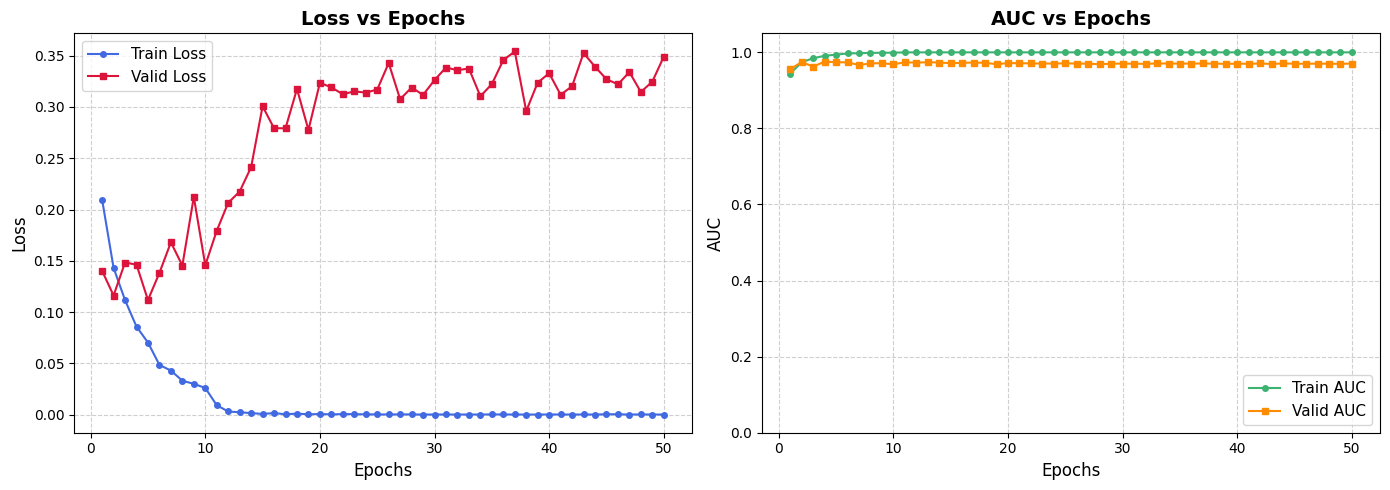


📁 保存的模型文件:
  - epoch_10_train_auc_0.9991_valid_auc_0.9686.pth
  - epoch_10_train_auc_0.9995_valid_auc_0.9774.pth
  - epoch_11_train_auc_0.9999_valid_auc_0.9739.pth
  - epoch_11_train_auc_1.0000_valid_auc_0.9778.pth
  - epoch_12_train_auc_1.0000_valid_auc_0.9729.pth
  ... 以及其他 62 个模型文件


In [ ]:
# model training with ROI data
import torch
import torch
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score 

class ROIDataset(Dataset):
    def __init__(self, roi_files, json_files, transform=None):
        self.roi_files = roi_files
        self.json_files = json_files
        self.transform = transform
    
    def __len__(self):
        return len(self.roi_files)
    
    def __getitem__(self, idx):
        roi_path = self.roi_files[idx]
        json_path = self.json_files[idx]
        
        if not os.path.exists(roi_path):
            raise FileNotFoundError(f"ROI file not found: {roi_path}")
        if not os.path.exists(json_path):
            raise FileNotFoundError(f"JSON file not found: {json_path}")
        
        roi_img = Image.open(roi_path).convert("RGB")
        
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        label = int(data['shapes'][0]['label'])
        
        if self.transform:
            roi_img = self.transform(roi_img)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return roi_img, label_tensor

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_roi_files = aug_train_roi_jpg     
train_json_files = combined_train_json  
valid_roi_files = valid_roi_jpg
valid_json_files = valid_json
test_roi_files = test_roi_jpg
test_json_files = test_json

print(f"训练集(含增强) ROI 文件数量: {len(train_roi_files)}")
print(f"训练集(含增强) JSON 文件数量: {len(train_json_files)}")
print(f"验证集 ROI 文件数量: {len(valid_roi_files)}")
print(f"验证集 JSON 文件数量: {len(valid_json_files)}")

assert len(train_roi_files) == len(train_json_files), "训练集ROI和JSON文件数量不匹配"
assert len(valid_roi_files) == len(valid_json_files), "验证集ROI和JSON文件数量不匹配"

train_dataset = ROIDataset(train_roi_files, train_json_files, transform=transform)
valid_dataset = ROIDataset(valid_roi_files, valid_json_files, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

print(f"训练集样本总数: {len(train_dataset)}")
print(f"验证集样本总数: {len(valid_dataset)}")

def check_label_distribution(dataset, name):
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label.item())
    unique, counts = np.unique(labels, return_counts=True)
    print(f"{name}标签分布: {dict(zip(unique, counts))}")

check_label_distribution(train_dataset, "训练集(含增强)")
check_label_distribution(valid_dataset, "验证集")

model_escc = models.densenet201(pretrained=False) 
num_ftrs = model_escc.classifier.in_features
model_escc.classifier = nn.Linear(num_ftrs, 2)  
model_escc = model_escc.to('cuda')

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_escc.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  

model_save_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_DenseNet_pth"
os.makedirs(model_save_path, exist_ok=True)
print(f"模型将保存到: {model_save_path}")

num_epochs = 50
train_losses, valid_losses = [], []
train_aucs, valid_aucs = [], []  
train_accs, valid_accs = [], []  
best_valid_auc = 0.0

for epoch in range(num_epochs):
    running_loss = 0.0
    correct_train = 0  
    total_train = 0    
    
    epoch_train_probs = []
    epoch_train_labels = []
    
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False, ncols=110)
    
    for inputs, labels in train_pbar:
        inputs = inputs.to('cuda')
        labels = labels.to('cuda')

        optimizer.zero_grad()
        outputs = model_escc(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        epoch_train_probs.extend(probs.detach().cpu().numpy())
        epoch_train_labels.extend(labels.cpu().numpy())
        
        current_loss = running_loss / (train_pbar.n + 1)
        current_acc = correct_train / total_train  # 实时 Acc
        try:
            current_auc = roc_auc_score(epoch_train_labels, epoch_train_probs)
        except ValueError:
            current_auc = 0.0
            
        train_pbar.set_postfix({'Loss': f'{current_loss:.4f}', 'AUC': f'{current_auc:.4f}', 'Acc': f'{current_acc:.4f}'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train  # 最终 Train Acc
    try: epoch_train_auc = roc_auc_score(epoch_train_labels, epoch_train_probs)
    except ValueError: epoch_train_auc = 0.0
    
    train_losses.append(epoch_loss)
    train_aucs.append(epoch_train_auc)
    train_accs.append(epoch_train_acc)  
    
    model_escc.eval()
    valid_loss = 0.0
    correct_valid = 0 
    total_valid = 0    
    
    epoch_valid_probs = []
    epoch_valid_labels = []
    
    valid_pbar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]', leave=False, ncols=110)
    
    with torch.no_grad():
        for inputs, labels in valid_pbar:
            inputs = inputs.to('cuda')
            labels = labels.to('cuda')

            outputs = model_escc(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            correct_valid += (predicted == labels).sum().item()
            total_valid += labels.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            epoch_valid_probs.extend(probs.cpu().numpy())
            epoch_valid_labels.extend(labels.cpu().numpy())
            
            current_loss = valid_loss / (valid_pbar.n + 1)
            current_acc = correct_valid / total_valid  # 实时 Acc
            try:
                current_auc = roc_auc_score(epoch_valid_labels, epoch_valid_probs)
            except ValueError:
                current_auc = 0.0
                
            valid_pbar.set_postfix({'Loss': f'{current_loss:.4f}', 'AUC': f'{current_auc:.4f}', 'Acc': f'{current_acc:.4f}'})
    
    epoch_valid_loss = valid_loss / len(valid_loader)
    epoch_valid_acc = correct_valid / total_valid  
    try: epoch_valid_auc = roc_auc_score(epoch_valid_labels, epoch_valid_probs)
    except ValueError: epoch_valid_auc = 0.0
    
    valid_losses.append(epoch_valid_loss)
    valid_aucs.append(epoch_valid_auc)
    valid_accs.append(epoch_valid_acc)  
    
    if epoch_valid_auc > best_valid_auc:
        best_valid_auc = epoch_valid_auc
    
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f}, AUC: {epoch_train_auc:.4f}, Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_valid_loss:.4f}, AUC: {epoch_valid_auc:.4f}, Acc: {epoch_valid_acc:.4f}")
    
    epoch_model_path = os.path.join(model_save_path, f"epoch_{epoch+1}_train_auc_{epoch_train_auc:.4f}_valid_auc_{epoch_valid_auc:.4f}.pth")
    torch.save(model_escc.state_dict(), epoch_model_path)

print(f"\n🎉 训练完成! 最佳验证集 AUC: {best_valid_auc:.4f}")

training_history = {
    'train_losses': train_losses,
    'train_aucs': train_aucs,
    'train_accs': train_accs,  
    'valid_losses': valid_losses,
    'valid_aucs': valid_aucs,
    'valid_accs': valid_accs,  
    'best_valid_auc': best_valid_auc
}

history_path = os.path.join(model_save_path, 'training_history.json')
with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(training_history, f, indent=4, ensure_ascii=False)
print(f"📊 训练历史已保存: {history_path}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='royalblue', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_losses, label='Valid Loss', color='crimson', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_aucs, label='Train AUC', color='mediumseagreen', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_aucs, label='Valid AUC', color='darkorange', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Epochs', fontsize=14, fontweight='bold')
plt.ylim([0.0, 1.05])  
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
curve_path = os.path.join(model_save_path, 'training_curves_auc.png')
plt.savefig(curve_path, dpi=300, bbox_inches='tight')
print(f"📈 训练曲线图已保存: {curve_path}")
plt.show()

print("\n📁 保存的模型文件:")
model_files = [f for f in os.listdir(model_save_path) if f.endswith('.pth')]
model_files.sort()
for model_file in model_files[:5]:
    print(f"  - {model_file}")
if len(model_files) > 5:
    print(f"  ... 以及其他 {len(model_files) - 5} 个模型文件")

# Other models

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import json
import os
import numpy as np

# 1. dataset definition
class ROIDataset(Dataset):
    def __init__(self, roi_files, json_files, transform=None):
        self.roi_files = roi_files
        self.json_files = json_files
        self.transform = transform
    
    def __len__(self):
        return len(self.roi_files)
    
    def __getitem__(self, idx):
        roi_path = self.roi_files[idx]
        json_path = self.json_files[idx]
        
        if not os.path.exists(roi_path):
            raise FileNotFoundError(f"ROI file not found: {roi_path}")
        if not os.path.exists(json_path):
            raise FileNotFoundError(f"JSON file not found: {json_path}")
        
        roi_img = Image.open(roi_path).convert("RGB")
        
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        label = int(data['shapes'][0]['label'])
        
        if self.transform:
            roi_img = self.transform(roi_img)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return roi_img, label_tensor

# 2. define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. prepare file lists for DataLoader
train_roi_files = aug_train_roi_jpg     
train_json_files = combined_train_json  
valid_roi_files = valid_roi_jpg
valid_json_files = valid_json

print(f"训练集(含增强) ROI 文件数量: {len(train_roi_files)}")
print(f"训练集(含增强) JSON 文件数量: {len(train_json_files)}")
print(f"验证集 ROI 文件数量: {len(valid_roi_files)}")
print(f"验证集 JSON 文件数量: {len(valid_json_files)}")

assert len(train_roi_files) == len(train_json_files), "训练集ROI和JSON文件数量不匹配"
assert len(valid_roi_files) == len(valid_json_files), "验证集ROI和JSON文件数量不匹配"

train_dataset = ROIDataset(train_roi_files, train_json_files, transform=transform)
valid_dataset = ROIDataset(valid_roi_files, valid_json_files, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

print(f"\n训练集样本总数: {len(train_dataset)}")
print(f"验证集样本总数: {len(valid_dataset)}")

def check_label_distribution(dataset, name):
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label.item())
    unique, counts = np.unique(labels, return_counts=True)
    print(f"{name} 标签分布: {dict(zip(unique, counts))}")

check_label_distribution(train_dataset, "训练集(含增强)")
check_label_distribution(valid_dataset, "验证集")

print("\n✅ Cell 0 运行完毕！数据已加载入 DataLoader，可以开始运行后面的各个模型 Cell 了。")

训练集(含增强) ROI 文件数量: 17524
训练集(含增强) JSON 文件数量: 17524
验证集 ROI 文件数量: 2121
验证集 JSON 文件数量: 2121

训练集样本总数: 17524
验证集样本总数: 2121
训练集(含增强) 标签分布: {0: 14844, 1: 2680}
验证集 标签分布: {0: 1962, 1: 159}

✅ Cell 0 运行完毕！数据已加载入 DataLoader，可以开始运行后面的各个模型 Cell 了。


In [ ]:
# model 1: resnet50
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

MODEL_NAME = "ResNet50"
model_save_path = fr"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_{MODEL_NAME}_pth"
os.makedirs(model_save_path, exist_ok=True)
print(f"🚀 开始训练 {MODEL_NAME}，模型将保存至: {model_save_path}")

# 1. 创建 ResNet50 模型
model_escc = models.resnet50(pretrained=True)
num_ftrs = model_escc.fc.in_features
model_escc.fc = nn.Linear(num_ftrs, 2)  # 修改分类层
model_escc = model_escc.to('cuda')

# 2. 损失函数与优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_escc.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 3. 训练主循环
num_epochs = 50
train_losses, valid_losses, train_aucs, valid_aucs, train_accs, valid_accs = [], [], [], [], [], []
best_valid_auc = 0.0

for epoch in range(num_epochs):
    # --- 训练 ---
    model_escc.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    epoch_train_probs, epoch_train_labels = [], []
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False, ncols=110)
    
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model_escc(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        epoch_train_probs.extend(probs.detach().cpu().numpy())
        epoch_train_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    try: epoch_train_auc = roc_auc_score(epoch_train_labels, epoch_train_probs)
    except: epoch_train_auc = 0.0
    
    # --- 验证 ---
    model_escc.eval()
    valid_loss, correct_valid, total_valid = 0.0, 0, 0
    epoch_valid_probs, epoch_valid_labels = [], []
    valid_pbar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]', leave=False, ncols=110)
    
    with torch.no_grad():
        for inputs, labels in valid_pbar:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            outputs = model_escc(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct_valid += (predicted == labels).sum().item()
            total_valid += labels.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            epoch_valid_probs.extend(probs.cpu().numpy())
            epoch_valid_labels.extend(labels.cpu().numpy())
            
    epoch_valid_loss = valid_loss / len(valid_loader)
    epoch_valid_acc = correct_valid / total_valid
    try: epoch_valid_auc = roc_auc_score(epoch_valid_labels, epoch_valid_probs)
    except: epoch_valid_auc = 0.0
    
    # 记录与保存
    train_losses.append(epoch_loss); train_aucs.append(epoch_train_auc); train_accs.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss); valid_aucs.append(epoch_valid_auc); valid_accs.append(epoch_valid_acc)
    
    if epoch_valid_auc > best_valid_auc: best_valid_auc = epoch_valid_auc
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f}, AUC: {epoch_train_auc:.4f}, Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_valid_loss:.4f}, AUC: {epoch_valid_auc:.4f}, Acc: {epoch_valid_acc:.4f}")
    
    epoch_model_path = os.path.join(model_save_path, f"epoch_{epoch+1}_train_auc_{epoch_train_auc:.4f}_valid_auc_{epoch_valid_auc:.4f}.pth")
    torch.save(model_escc.state_dict(), epoch_model_path)

print(f"\n🎉 {MODEL_NAME} 训练完成! 最佳验证集 AUC: {best_valid_auc:.4f}")

# 保存训练历史 (将 Acc 也存入 json)
training_history = {
    'train_losses': train_losses,
    'train_aucs': train_aucs,
    'train_accs': train_accs,  
    'valid_losses': valid_losses,
    'valid_aucs': valid_aucs,
    'valid_accs': valid_accs,  
    'best_valid_auc': best_valid_auc
}

history_path = os.path.join(model_save_path, 'training_history_resnet.json')
with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(training_history, f, indent=4, ensure_ascii=False)
print(f"📊 训练历史已保存: {history_path}")

# ==========================================
# 绘制 Loss 和 AUC 曲线
# ==========================================
plt.figure(figsize=(14, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='royalblue', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_losses, label='Valid Loss', color='crimson', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 绘制 AUC 曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_aucs, label='Train AUC', color='mediumseagreen', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_aucs, label='Valid AUC', color='darkorange', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Epochs', fontsize=14, fontweight='bold')
plt.ylim([0.0, 1.05])  
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# curve_path = os.path.join(model_save_path, 'training_curves_auc.png')
# plt.savefig(curve_path, dpi=300, bbox_inches='tight')
# print(f"📈 训练曲线图已保存: {curve_path}")
plt.show()

# 显示最终模型文件列表
print("\n📁 保存的模型文件:")
model_files = [f for f in os.listdir(model_save_path) if f.endswith('.pth')]
model_files.sort()
for model_file in model_files[:5]: # 只显示前5个防止刷屏
    print(f"  - {model_file}")
if len(model_files) > 5:
    print(f"  ... 以及其他 {len(model_files) - 5} 个模型文件")

d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


🚀 开始训练 ResNet50，模型将保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_ResNet50_pth


Epoch 1/50 | Train Loss: 0.2889, AUC: 0.8837, Acc: 0.8750 | Valid Loss: 0.1950, AUC: 0.9379, Acc: 0.9151


Epoch 2/50 | Train Loss: 0.2016, AUC: 0.9487, Acc: 0.9106 | Valid Loss: 0.1921, AUC: 0.9267, Acc: 0.9024


Epoch 3/50 | Train Loss: 0.1566, AUC: 0.9695, Acc: 0.9343 | Valid Loss: 0.2872, AUC: 0.9477, Acc: 0.8694


...

Epoch 18/50 | Train Loss: 0.0007, AUC: 1.0000, Acc: 0.9998 | Valid Loss: 0.2800, AUC: 0.9643, Acc: 0.9448


Epoch 19/50 | Train Loss: 0.0002, AUC: 1.0000, Acc: 1.0000 | Valid Loss: 0.2653, AUC: 0.9679, Acc: 0.9486


Epoch 20/50 | Train Loss: 0.0001, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.2895, AUC: 0.9690, Acc: 0.9486


Epoch 21/50 | Train Loss: 0.0001, AUC: 1.0000, Acc: 1.0000 | Valid Loss: 0.2938, AUC: 0.9681, Acc: 0.9448


KeyboardInterrupt: 

In [ ]:
# model 2: EfficientNet_B4
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

MODEL_NAME = "EfficientNet_B4"
model_save_path = fr"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_{MODEL_NAME}_pth"
os.makedirs(model_save_path, exist_ok=True)
print(f"🚀 开始训练 {MODEL_NAME}，模型将保存至: {model_save_path}")

# 1. 创建 EfficientNet-B4 模型
model_escc = models.efficientnet_b4(pretrained=True)
# EfficientNet 的线性分类层在 classifier 的第 1 个位置 (索引为1)
num_ftrs = model_escc.classifier[1].in_features
model_escc.classifier[1] = nn.Linear(num_ftrs, 2)
model_escc = model_escc.to('cuda')

# 2. 损失函数与优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_escc.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 3. 训练主循环 (与 ResNet 完全一致)
num_epochs = 50
train_losses, valid_losses, train_aucs, valid_aucs, train_accs, valid_accs = [], [], [], [], [], []
best_valid_auc = 0.0

for epoch in range(num_epochs):
    # --- 训练 ---
    model_escc.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    epoch_train_probs, epoch_train_labels = [], []
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False, ncols=110)
    
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model_escc(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        epoch_train_probs.extend(probs.detach().cpu().numpy())
        epoch_train_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    try: epoch_train_auc = roc_auc_score(epoch_train_labels, epoch_train_probs)
    except: epoch_train_auc = 0.0
    
    # --- 验证 ---
    model_escc.eval()
    valid_loss, correct_valid, total_valid = 0.0, 0, 0
    epoch_valid_probs, epoch_valid_labels = [], []
    valid_pbar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]', leave=False, ncols=110)
    
    with torch.no_grad():
        for inputs, labels in valid_pbar:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            outputs = model_escc(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct_valid += (predicted == labels).sum().item()
            total_valid += labels.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            epoch_valid_probs.extend(probs.cpu().numpy())
            epoch_valid_labels.extend(labels.cpu().numpy())
            
    epoch_valid_loss = valid_loss / len(valid_loader)
    epoch_valid_acc = correct_valid / total_valid
    try: epoch_valid_auc = roc_auc_score(epoch_valid_labels, epoch_valid_probs)
    except: epoch_valid_auc = 0.0
    
    # 记录与保存
    train_losses.append(epoch_loss); train_aucs.append(epoch_train_auc); train_accs.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss); valid_aucs.append(epoch_valid_auc); valid_accs.append(epoch_valid_acc)
    
    if epoch_valid_auc > best_valid_auc: best_valid_auc = epoch_valid_auc
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f}, AUC: {epoch_train_auc:.4f}, Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_valid_loss:.4f}, AUC: {epoch_valid_auc:.4f}, Acc: {epoch_valid_acc:.4f}")
    
    epoch_model_path = os.path.join(model_save_path, f"epoch_{epoch+1}_train_auc_{epoch_train_auc:.4f}_valid_auc_{epoch_valid_auc:.4f}.pth")
    torch.save(model_escc.state_dict(), epoch_model_path)

print(f"\n🎉 {MODEL_NAME} 训练完成! 最佳验证集 AUC: {best_valid_auc:.4f}")

# 保存训练历史 (将 Acc 也存入 json)
training_history = {
    'train_losses': train_losses,
    'train_aucs': train_aucs,
    'train_accs': train_accs,  
    'valid_losses': valid_losses,
    'valid_aucs': valid_aucs,
    'valid_accs': valid_accs,  
    'best_valid_auc': best_valid_auc
}

history_path = os.path.join(model_save_path, 'training_history_efficientnet.json')
with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(training_history, f, indent=4, ensure_ascii=False)
print(f"📊 训练历史已保存: {history_path}")

# ==========================================
# 绘制 Loss 和 AUC 曲线
# ==========================================
plt.figure(figsize=(14, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='royalblue', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_losses, label='Valid Loss', color='crimson', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 绘制 AUC 曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_aucs, label='Train AUC', color='mediumseagreen', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_aucs, label='Valid AUC', color='darkorange', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Epochs', fontsize=14, fontweight='bold')
plt.ylim([0.0, 1.05])  
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# curve_path = os.path.join(model_save_path, 'training_curves_auc.png')
# plt.savefig(curve_path, dpi=300, bbox_inches='tight')
# print(f"📈 训练曲线图已保存: {curve_path}")
plt.show()

# 显示最终模型文件列表
print("\n📁 保存的模型文件:")
model_files = [f for f in os.listdir(model_save_path) if f.endswith('.pth')]
model_files.sort()
for model_file in model_files[:5]: # 只显示前5个防止刷屏
    print(f"  - {model_file}")
if len(model_files) > 5:
    print(f"  ... 以及其他 {len(model_files) - 5} 个模型文件")

🚀 开始训练 EfficientNet_B4，模型将保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_EfficientNet_B4_pth


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:11<00:00, 6.86MB/s]


Epoch 1/50 | Train Loss: 0.1775, AUC: 0.9605, Acc: 0.9248 | Valid Loss: 0.1208, AUC: 0.9754, Acc: 0.9538


Epoch 2/50 | Train Loss: 0.0944, AUC: 0.9887, Acc: 0.9631 | Valid Loss: 0.1215, AUC: 0.9734, Acc: 0.9505


Epoch 3/50 | Train Loss: 0.0550, AUC: 0.9961, Acc: 0.9794 | Valid Loss: 0.1228, AUC: 0.9746, Acc: 0.9524


...

Epoch 5/50 | Train Loss: 0.0168, AUC: 0.9996, Acc: 0.9944 | Valid Loss: 0.1874, AUC: 0.9718, Acc: 0.9529


Epoch 6/50 | Train Loss: 0.0138, AUC: 0.9997, Acc: 0.9957 | Valid Loss: 0.1770, AUC: 0.9736, Acc: 0.9538


Epoch 7/50 | Train Loss: 0.0122, AUC: 0.9998, Acc: 0.9957 | Valid Loss: 0.2007, AUC: 0.9733, Acc: 0.9514


Epoch 8/50 | Train Loss: 0.0091, AUC: 0.9999, Acc: 0.9969 | Valid Loss: 0.2268, AUC: 0.9714, Acc: 0.9510


KeyboardInterrupt: 

In [ ]:
# model 3: Inception_v3 
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

MODEL_NAME = "Inception_v3"
model_save_path = fr"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_{MODEL_NAME}_pth"
os.makedirs(model_save_path, exist_ok=True)
print(f"🚀 开始训练 {MODEL_NAME}，模型将保存至: {model_save_path}")

# 1. 创建 Inception_v3 模型
# 【破解步骤 1】：顺从 PyTorch，正常加载预训练权重（此时内部会自动设 aux_logits=True）
model_escc = models.inception_v3(pretrained=True)

# 【破解步骤 2】：外科手术式切除！手动关闭辅助机制，并把辅助分支对象置空
model_escc.aux_logits = False
model_escc.AuxLogits = None 

# 3. 正常修改主分类器
num_ftrs = model_escc.fc.in_features
model_escc.fc = nn.Linear(num_ftrs, 2)
model_escc = model_escc.to('cuda')

# 2. 损失函数与优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_escc.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 3. 训练主循环
num_epochs = 50
train_losses, valid_losses, train_aucs, valid_aucs, train_accs, valid_accs = [], [], [], [], [], []
best_valid_auc = 0.0

for epoch in range(num_epochs):
    # --- 训练 ---
    model_escc.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    epoch_train_probs, epoch_train_labels = [], []
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False, ncols=110)
    
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        
        # 由于我们已经彻底切除了辅助分支，这里可以像普通网络一样进行简单的前向传播
        outputs = model_escc(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        epoch_train_probs.extend(probs.detach().cpu().numpy())
        epoch_train_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    try: epoch_train_auc = roc_auc_score(epoch_train_labels, epoch_train_probs)
    except: epoch_train_auc = 0.0
    
    # --- 验证 ---
    model_escc.eval()
    valid_loss, correct_valid, total_valid = 0.0, 0, 0
    epoch_valid_probs, epoch_valid_labels = [], []
    valid_pbar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]', leave=False, ncols=110)
    
    with torch.no_grad():
        for inputs, labels in valid_pbar:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            
            outputs = model_escc(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct_valid += (predicted == labels).sum().item()
            total_valid += labels.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            epoch_valid_probs.extend(probs.cpu().numpy())
            epoch_valid_labels.extend(labels.cpu().numpy())
            
    epoch_valid_loss = valid_loss / len(valid_loader)
    epoch_valid_acc = correct_valid / total_valid
    try: epoch_valid_auc = roc_auc_score(epoch_valid_labels, epoch_valid_probs)
    except: epoch_valid_auc = 0.0
    
    # 记录与保存
    train_losses.append(epoch_loss); train_aucs.append(epoch_train_auc); train_accs.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss); valid_aucs.append(epoch_valid_auc); valid_accs.append(epoch_valid_acc)
    
    if epoch_valid_auc > best_valid_auc: best_valid_auc = epoch_valid_auc
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f}, AUC: {epoch_train_auc:.4f}, Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_valid_loss:.4f}, AUC: {epoch_valid_auc:.4f}, Acc: {epoch_valid_acc:.4f}")
    
    epoch_model_path = os.path.join(model_save_path, f"epoch_{epoch+1}_train_auc_{epoch_train_auc:.4f}_valid_auc_{epoch_valid_auc:.4f}.pth")
    torch.save(model_escc.state_dict(), epoch_model_path)

print(f"\n🎉 {MODEL_NAME} 训练完成! 最佳验证集 AUC: {best_valid_auc:.4f}")

# 保存训练历史 (将 Acc 也存入 json)
training_history = {
    'train_losses': train_losses,
    'train_aucs': train_aucs,
    'train_accs': train_accs,  
    'valid_losses': valid_losses,
    'valid_aucs': valid_aucs,
    'valid_accs': valid_accs,  
    'best_valid_auc': best_valid_auc
}

history_path = os.path.join(model_save_path, 'training_history_inception.json')
with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(training_history, f, indent=4, ensure_ascii=False)
print(f"📊 训练历史已保存: {history_path}")

# ==========================================
# 绘制 Loss 和 AUC 曲线
# ==========================================
plt.figure(figsize=(14, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='royalblue', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_losses, label='Valid Loss', color='crimson', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 绘制 AUC 曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_aucs, label='Train AUC', color='mediumseagreen', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_aucs, label='Valid AUC', color='darkorange', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Epochs', fontsize=14, fontweight='bold')
plt.ylim([0.0, 1.05])  
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# curve_path = os.path.join(model_save_path, 'training_curves_auc.png')
# plt.savefig(curve_path, dpi=300, bbox_inches='tight')
# print(f"📈 训练曲线图已保存: {curve_path}")
plt.show()

# 显示最终模型文件列表
print("\n📁 保存的模型文件:")
model_files = [f for f in os.listdir(model_save_path) if f.endswith('.pth')]
model_files.sort()
for model_file in model_files[:5]: # 只显示前5个防止刷屏
    print(f"  - {model_file}")
if len(model_files) > 5:
    print(f"  ... 以及其他 {len(model_files) - 5} 个模型文件")

🚀 开始训练 Inception_v3，模型将保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_Inception_v3_pth


Epoch 1/50 | Train Loss: 0.1538, AUC: 0.9694, Acc: 0.9381 | Valid Loss: 0.1448, AUC: 0.9785, Acc: 0.9415


Epoch 2/50 | Train Loss: 0.0871, AUC: 0.9901, Acc: 0.9683 | Valid Loss: 0.1414, AUC: 0.9740, Acc: 0.9552


Epoch 3/50 | Train Loss: 0.0576, AUC: 0.9955, Acc: 0.9796 | Valid Loss: 0.1346, AUC: 0.9777, Acc: 0.9533


Epoch 4/50 | Train Loss: 0.0373, AUC: 0.9980, Acc: 0.9869 | Valid Loss: 0.2059, AUC: 0.9781, Acc: 0.9500


...

Epoch 24/50 | Train Loss: 0.0002, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.5180, AUC: 0.9714, Acc: 0.9514


Epoch 25/50 | Train Loss: 0.0000, AUC: 1.0000, Acc: 1.0000 | Valid Loss: 0.5226, AUC: 0.9710, Acc: 0.9496


Epoch 26/50 | Train Loss: 0.0000, AUC: 1.0000, Acc: 1.0000 | Valid Loss: 0.4917, AUC: 0.9717, Acc: 0.9510


Epoch 27/50 | Train Loss: 0.0000, AUC: 1.0000, Acc: 1.0000 | Valid Loss: 0.5511, AUC: 0.9703, Acc: 0.9510


KeyboardInterrupt: 

In [ ]:
# model 4: ConvNeXt_Tiny
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

MODEL_NAME = "ConvNeXt_Tiny"
model_save_path = fr"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_{MODEL_NAME}_pth"
os.makedirs(model_save_path, exist_ok=True)
print(f"🚀 开始训练 {MODEL_NAME}，模型将保存至: {model_save_path}")

# 1. 创建 ConvNeXt-Tiny 模型
model_escc = models.convnext_tiny(pretrained=True)
# ConvNeXt 的线性分类层在 classifier 的第 2 个位置 (索引为2)
num_ftrs = model_escc.classifier[2].in_features
model_escc.classifier[2] = nn.Linear(num_ftrs, 2)
model_escc = model_escc.to('cuda')

# 2. 损失函数与优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_escc.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 3. 训练主循环 (与 ResNet 完全一致)
num_epochs = 50
train_losses, valid_losses, train_aucs, valid_aucs, train_accs, valid_accs = [], [], [], [], [], []
best_valid_auc = 0.0

for epoch in range(num_epochs):
    # --- 训练 ---
    model_escc.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    epoch_train_probs, epoch_train_labels = [], []
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False, ncols=110)
    
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model_escc(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        epoch_train_probs.extend(probs.detach().cpu().numpy())
        epoch_train_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    try: epoch_train_auc = roc_auc_score(epoch_train_labels, epoch_train_probs)
    except: epoch_train_auc = 0.0
    
    # --- 验证 ---
    model_escc.eval()
    valid_loss, correct_valid, total_valid = 0.0, 0, 0
    epoch_valid_probs, epoch_valid_labels = [], []
    valid_pbar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]', leave=False, ncols=110)
    
    with torch.no_grad():
        for inputs, labels in valid_pbar:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            outputs = model_escc(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct_valid += (predicted == labels).sum().item()
            total_valid += labels.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            epoch_valid_probs.extend(probs.cpu().numpy())
            epoch_valid_labels.extend(labels.cpu().numpy())
            
    epoch_valid_loss = valid_loss / len(valid_loader)
    epoch_valid_acc = correct_valid / total_valid
    try: epoch_valid_auc = roc_auc_score(epoch_valid_labels, epoch_valid_probs)
    except: epoch_valid_auc = 0.0
    
    # 记录与保存
    train_losses.append(epoch_loss); train_aucs.append(epoch_train_auc); train_accs.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss); valid_aucs.append(epoch_valid_auc); valid_accs.append(epoch_valid_acc)
    
    if epoch_valid_auc > best_valid_auc: best_valid_auc = epoch_valid_auc
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f}, AUC: {epoch_train_auc:.4f}, Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_valid_loss:.4f}, AUC: {epoch_valid_auc:.4f}, Acc: {epoch_valid_acc:.4f}")
    
    epoch_model_path = os.path.join(model_save_path, f"epoch_{epoch+1}_train_auc_{epoch_train_auc:.4f}_valid_auc_{epoch_valid_auc:.4f}.pth")
    torch.save(model_escc.state_dict(), epoch_model_path)

print(f"\n🎉 {MODEL_NAME} 训练完成! 最佳验证集 AUC: {best_valid_auc:.4f}")

# 保存训练历史 (将 Acc 也存入 json)
training_history = {
    'train_losses': train_losses,
    'train_aucs': train_aucs,
    'train_accs': train_accs,  
    'valid_losses': valid_losses,
    'valid_aucs': valid_aucs,
    'valid_accs': valid_accs,  
    'best_valid_auc': best_valid_auc
}

history_path = os.path.join(model_save_path, 'training_history_convnext.json')
with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(training_history, f, indent=4, ensure_ascii=False)
print(f"📊 训练历史已保存: {history_path}")

# ==========================================
# 绘制 Loss 和 AUC 曲线
# ==========================================
plt.figure(figsize=(14, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='royalblue', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_losses, label='Valid Loss', color='crimson', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 绘制 AUC 曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_aucs, label='Train AUC', color='mediumseagreen', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_aucs, label='Valid AUC', color='darkorange', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Epochs', fontsize=14, fontweight='bold')
plt.ylim([0.0, 1.05])  
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# curve_path = os.path.join(model_save_path, 'training_curves_auc.png')
# plt.savefig(curve_path, dpi=300, bbox_inches='tight')
# print(f"📈 训练曲线图已保存: {curve_path}")
plt.show()

# 显示最终模型文件列表
print("\n📁 保存的模型文件:")
model_files = [f for f in os.listdir(model_save_path) if f.endswith('.pth')]
model_files.sort()
for model_file in model_files[:5]: # 只显示前5个防止刷屏
    print(f"  - {model_file}")
if len(model_files) > 5:
    print(f"  ... 以及其他 {len(model_files) - 5} 个模型文件")

🚀 开始训练 ConvNeXt_Tiny，模型将保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_ConvNeXt_Tiny_pth


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:21<00:00, 5.35MB/s] 


Epoch 1/50 | Train Loss: 0.1384, AUC: 0.9749, Acc: 0.9456 | Valid Loss: 0.1228, AUC: 0.9794, Acc: 0.9538


Epoch 2/50 | Train Loss: 0.0772, AUC: 0.9918, Acc: 0.9715 | Valid Loss: 0.1053, AUC: 0.9786, Acc: 0.9552


Epoch 3/50 | Train Loss: 0.0439, AUC: 0.9972, Acc: 0.9844 | Valid Loss: 0.1289, AUC: 0.9797, Acc: 0.9595


...

Epoch 39/50 | Train Loss: 0.0000, AUC: 1.0000, Acc: 1.0000 | Valid Loss: 0.4267, AUC: 0.9747, Acc: 0.9557


Epoch 40/50 | Train Loss: 0.0001, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.4272, AUC: 0.9747, Acc: 0.9552


Epoch 41/50 | Train Loss: 0.0002, AUC: 1.0000, Acc: 0.9999 | Valid Loss: 0.4272, AUC: 0.9747, Acc: 0.9552


Epoch 42/50 | Train Loss: 0.0000, AUC: 1.0000, Acc: 1.0000 | Valid Loss: 0.4272, AUC: 0.9747, Acc: 0.9552


KeyboardInterrupt: 

In [ ]:
# model 5: VGG16
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

MODEL_NAME = "VGG16"
model_save_path = fr"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_{MODEL_NAME}_pth"
os.makedirs(model_save_path, exist_ok=True)
print(f"🚀 开始训练 {MODEL_NAME}，模型将保存至: {model_save_path}")

# 1. 创建 VGG16 模型
model_escc = models.vgg16(pretrained=True)
# VGG16 的分类器最后是一个长序列，线性层在索引 6
num_ftrs = model_escc.classifier[6].in_features
model_escc.classifier[6] = nn.Linear(num_ftrs, 2)
model_escc = model_escc.to('cuda')

# 2. 损失函数与优化器
criterion = nn.CrossEntropyLoss()
# 💡 VGG16 参数极大，建议学习率设小一点防止发散
optimizer = optim.Adam(model_escc.parameters(), lr=0.00005) 
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 3. 训练主循环 (与 ResNet 完全一致)
num_epochs = 50
train_losses, valid_losses, train_aucs, valid_aucs, train_accs, valid_accs = [], [], [], [], [], []
best_valid_auc = 0.0

for epoch in range(num_epochs):
    # --- 训练 ---
    model_escc.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    epoch_train_probs, epoch_train_labels = [], []
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False, ncols=110)
    
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model_escc(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        epoch_train_probs.extend(probs.detach().cpu().numpy())
        epoch_train_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    try: epoch_train_auc = roc_auc_score(epoch_train_labels, epoch_train_probs)
    except: epoch_train_auc = 0.0
    
    # --- 验证 ---
    model_escc.eval()
    valid_loss, correct_valid, total_valid = 0.0, 0, 0
    epoch_valid_probs, epoch_valid_labels = [], []
    valid_pbar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]', leave=False, ncols=110)
    
    with torch.no_grad():
        for inputs, labels in valid_pbar:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            outputs = model_escc(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct_valid += (predicted == labels).sum().item()
            total_valid += labels.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            epoch_valid_probs.extend(probs.cpu().numpy())
            epoch_valid_labels.extend(labels.cpu().numpy())
            
    epoch_valid_loss = valid_loss / len(valid_loader)
    epoch_valid_acc = correct_valid / total_valid
    try: epoch_valid_auc = roc_auc_score(epoch_valid_labels, epoch_valid_probs)
    except: epoch_valid_auc = 0.0
    
    # 记录与保存
    train_losses.append(epoch_loss); train_aucs.append(epoch_train_auc); train_accs.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss); valid_aucs.append(epoch_valid_auc); valid_accs.append(epoch_valid_acc)
    
    if epoch_valid_auc > best_valid_auc: best_valid_auc = epoch_valid_auc
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f}, AUC: {epoch_train_auc:.4f}, Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_valid_loss:.4f}, AUC: {epoch_valid_auc:.4f}, Acc: {epoch_valid_acc:.4f}")
    
    epoch_model_path = os.path.join(model_save_path, f"epoch_{epoch+1}_train_auc_{epoch_train_auc:.4f}_valid_auc_{epoch_valid_auc:.4f}.pth")
    torch.save(model_escc.state_dict(), epoch_model_path)

print(f"\n🎉 {MODEL_NAME} 训练完成! 最佳验证集 AUC: {best_valid_auc:.4f}")

# 保存训练历史 (将 Acc 也存入 json)
training_history = {
    'train_losses': train_losses,
    'train_aucs': train_aucs,
    'train_accs': train_accs,  
    'valid_losses': valid_losses,
    'valid_aucs': valid_aucs,
    'valid_accs': valid_accs,  
    'best_valid_auc': best_valid_auc
}

history_path = os.path.join(model_save_path, 'training_history_vgg.json')
with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(training_history, f, indent=4, ensure_ascii=False)
print(f"📊 训练历史已保存: {history_path}")

# ==========================================
# 绘制 Loss 和 AUC 曲线
# ==========================================
plt.figure(figsize=(14, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='royalblue', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_losses, label='Valid Loss', color='crimson', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 绘制 AUC 曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_aucs, label='Train AUC', color='mediumseagreen', marker='o', markersize=4)
plt.plot(range(1, num_epochs + 1), valid_aucs, label='Valid AUC', color='darkorange', marker='s', markersize=4)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Epochs', fontsize=14, fontweight='bold')
plt.ylim([0.0, 1.05])  
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# curve_path = os.path.join(model_save_path, 'training_curves_auc.png')
# plt.savefig(curve_path, dpi=300, bbox_inches='tight')
# print(f"📈 训练曲线图已保存: {curve_path}")
plt.show()

# 显示最终模型文件列表
print("\n📁 保存的模型文件:")
model_files = [f for f in os.listdir(model_save_path) if f.endswith('.pth')]
model_files.sort()
for model_file in model_files[:5]: # 只显示前5个防止刷屏
    print(f"  - {model_file}")
if len(model_files) > 5:
    print(f"  ... 以及其他 {len(model_files) - 5} 个模型文件")

🚀 开始训练 VGG16，模型将保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_VGG16_pth


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [01:56<00:00, 4.76MB/s]   


Epoch 1/50 | Train Loss: 0.1570, AUC: 0.9702, Acc: 0.9380 | Valid Loss: 0.0976, AUC: 0.9808, Acc: 0.9580


Epoch 2/50 | Train Loss: 0.0915, AUC: 0.9898, Acc: 0.9655 | Valid Loss: 0.1324, AUC: 0.9787, Acc: 0.9519


KeyboardInterrupt: 

# models evaluation

🚀 正在加载 RetinaNet 目标检测器...
⏳ 正在批量提取测试集 ROI 并缓存至内存 (仅需执行一次)...


100%|██████████| 2131/2131 [01:00<00:00, 35.41it/s]


✅ 成功提取并缓存 2131 个测试样本的 ROI！

🔄 正在评估模型: ResNet50 ...
   -> 🎯 AUC: 0.9742 | ACC: 0.9479 | SEN: 0.8816 | SPE: 0.9530

🔄 正在评估模型: EfficientNet_B4 ...


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


   -> 🎯 AUC: 0.9703 | ACC: 0.9451 | SEN: 0.8289 | SPE: 0.9540

🔄 正在评估模型: Inception_v3 ...


...

   -> 🎯 AUC: 0.9751 | ACC: 0.9578 | SEN: 0.7961 | SPE: 0.9702

🔄 正在评估模型: VGG16 ...


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


   -> 🎯 AUC: 0.9747 | ACC: 0.9456 | SEN: 0.9211 | SPE: 0.9474

🔄 正在评估模型: DenseNet201 ...


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


   -> 🎯 AUC: 0.9759 | ACC: 0.9573 | SEN: 0.7368 | SPE: 0.9742



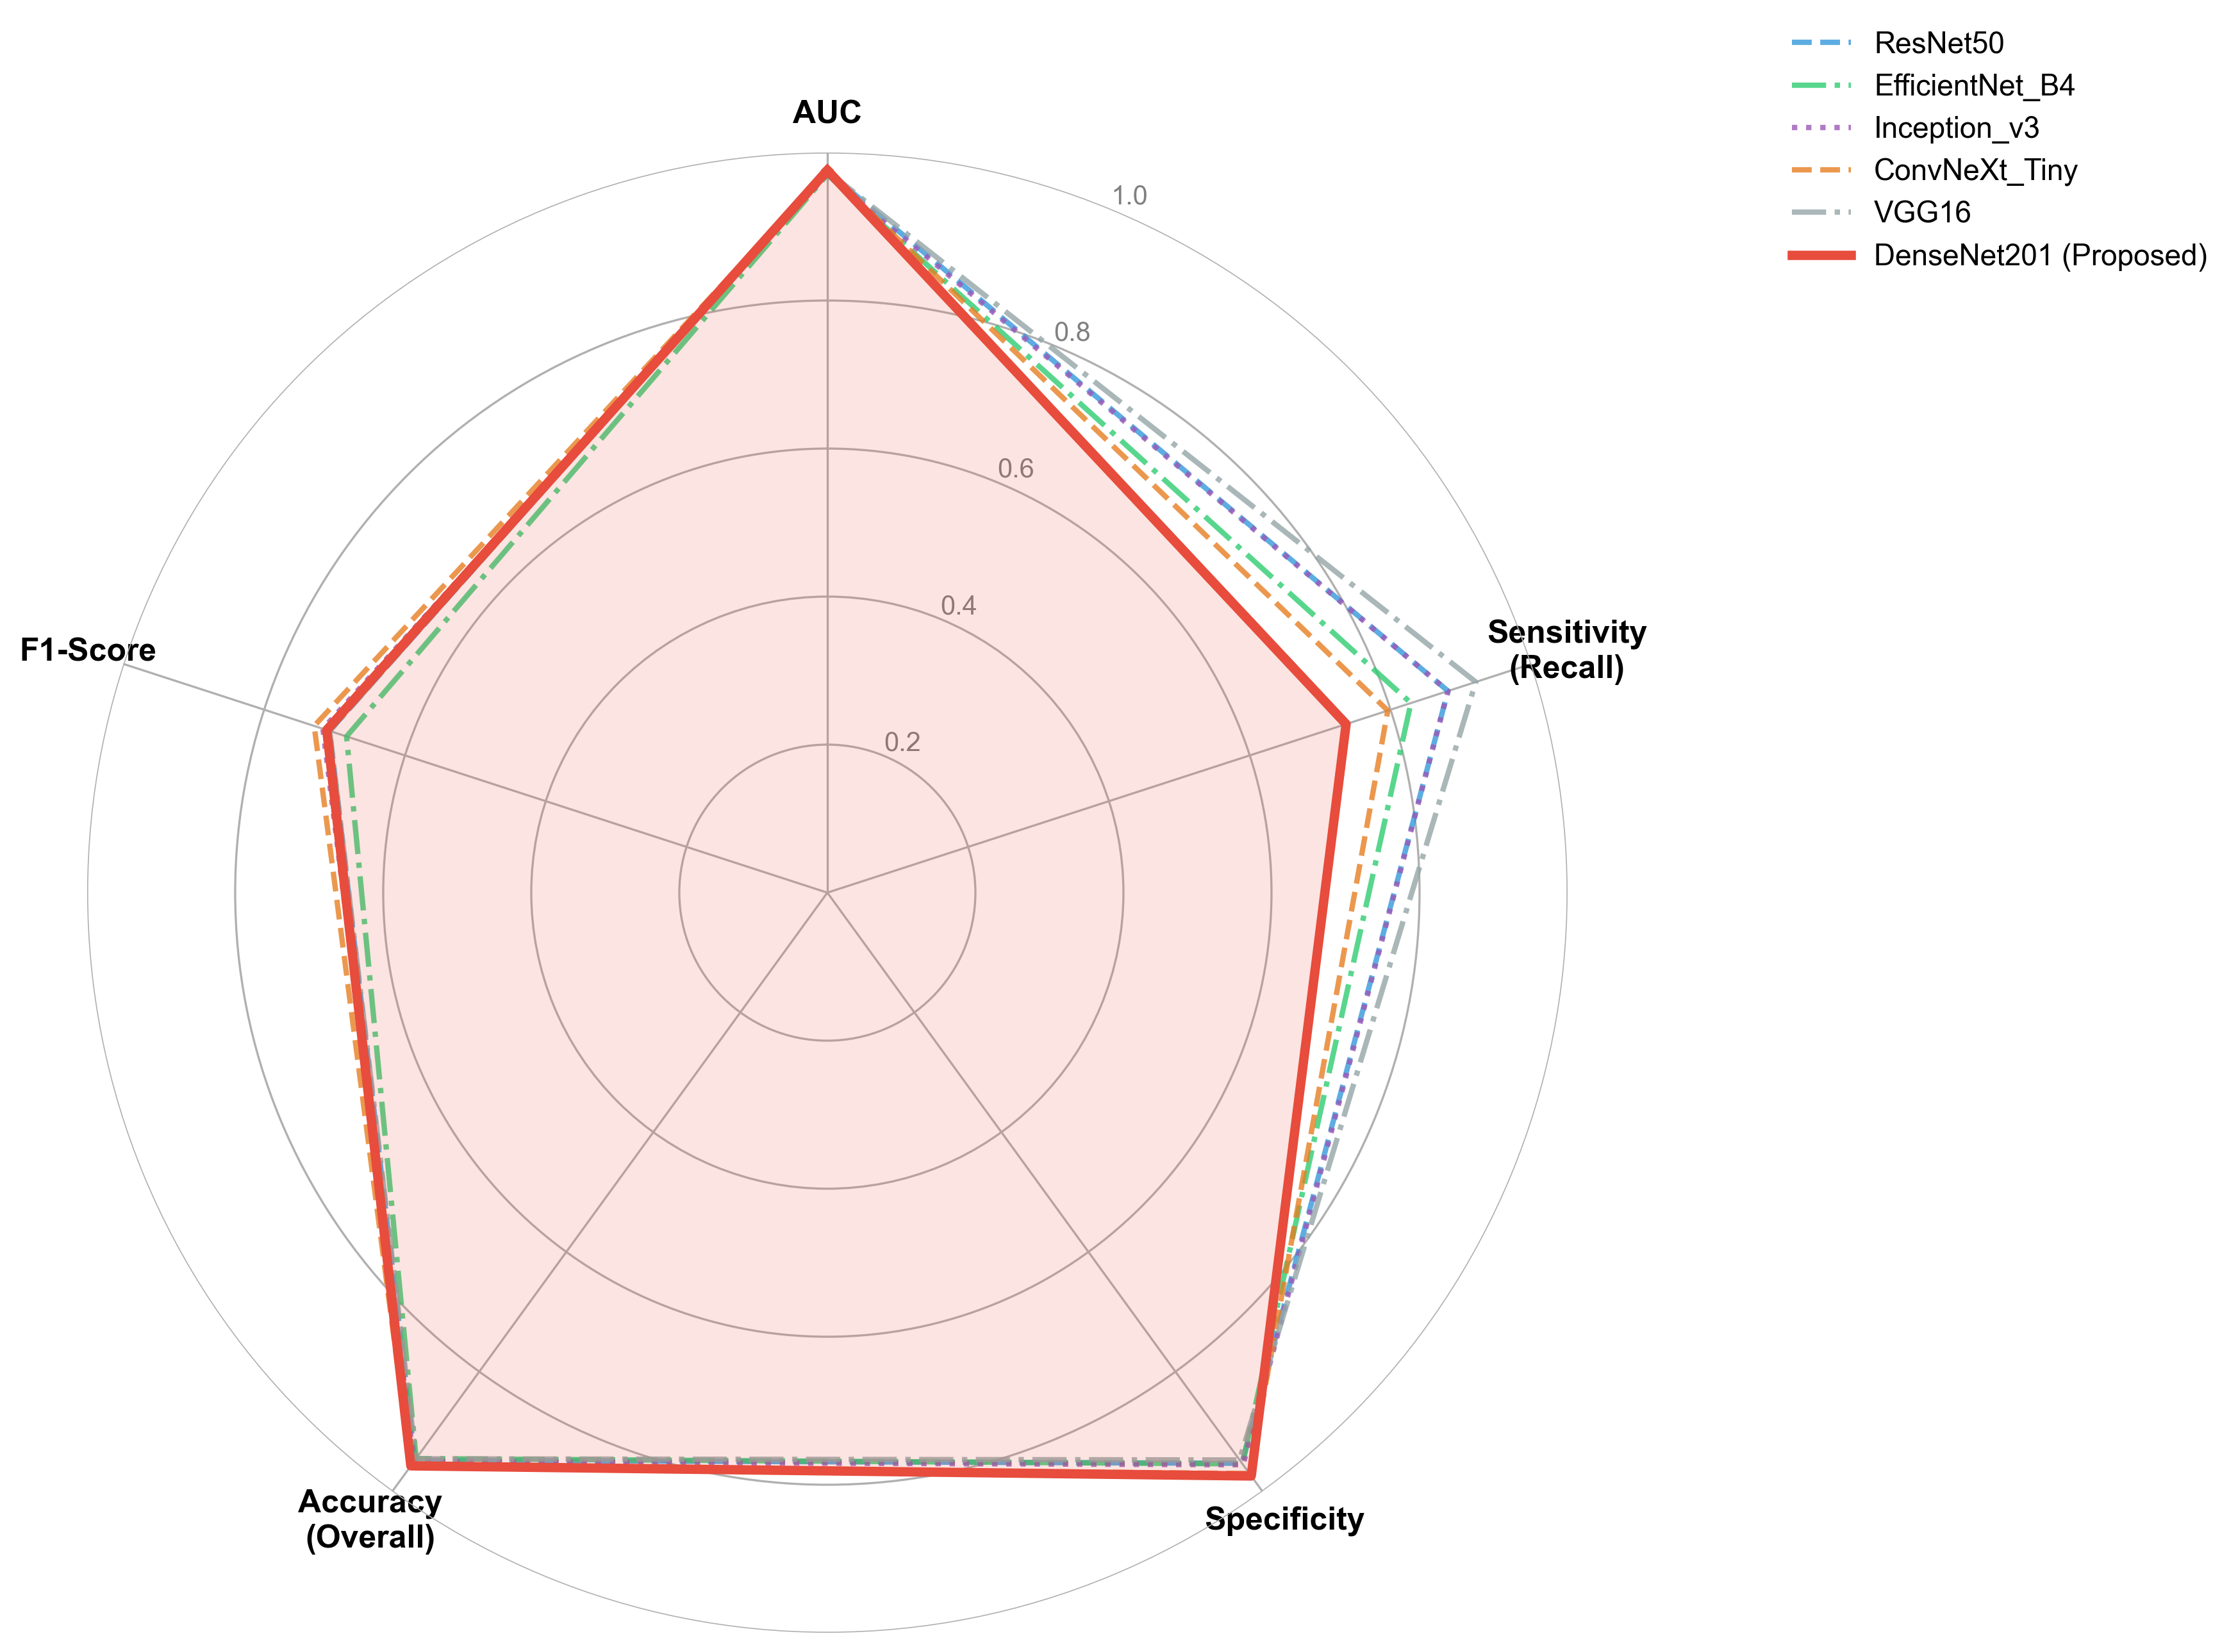

🎉 全部平行测试完成，雷达图已生成！


In [ ]:
import torch
import torchvision
from torchvision import models, transforms
import torch.nn as nn
from torchvision.transforms import functional as F
from PIL import Image
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from tqdm import tqdm
import pydicom

# 1. the six classification models' paths
MODEL_DICT = {
    "ResNet50": r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_ResNet50_pth\epoch_5_train_auc_0.9882_valid_auc_0.9715.pth",
    "EfficientNet_B4": r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_EfficientNet_B4_pth\epoch_3_train_auc_0.9961_valid_auc_0.9746.pth",
    "Inception_v3": r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_Inception_v3_pth\epoch_10_train_auc_0.9997_valid_auc_0.9797.pth",
    "ConvNeXt_Tiny": r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_ConvNeXt_Tiny_pth\epoch_3_train_auc_0.9972_valid_auc_0.9797.pth",
    "VGG16": r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_VGG16_pth\epoch_2_train_auc_0.9898_valid_auc_0.9787.pth",
    "DenseNet201": r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_DenseNet_pth\epoch_2_train_auc_0.9887_valid_auc_0.9808.pth"
}

# 2. RetinaNet for ROI extraction
print("🚀 正在加载 RetinaNet 目标检测器...")
retina_model = models.detection.retinanet_resnet50_fpn(pretrained=False, num_classes=3)
retina_weight = torch.load(r"D:\MED\SpM\SpM_pth\Retina\3_train_mIou_0.8730000257492065_valid_mIou_0.8809999823570251.pth")
retina_model.load_state_dict(retina_weight)
retina_model = retina_model.to('cuda')
retina_model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_dicom_image(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    img_array = ds.pixel_array
    return (img_array / np.max(img_array) * 255).astype(np.uint8)

def extract_roi_tensor(img_array):
    if len(img_array.shape) == 2:
        img_array = np.stack([img_array] * 3, axis=-1)
    img_tensor = F.to_tensor(img_array).unsqueeze(0).to('cuda')
    
    with torch.no_grad():
        prediction = retina_model(img_tensor)

    if len(prediction) > 0 and len(prediction[0]['scores']) > 0:
        pred_boxes = prediction[0]['boxes'].cpu().numpy()
        pred_scores = prediction[0]['scores'].cpu().numpy()
        if len(pred_scores) > 0:
            max_idx = np.argmax(pred_scores)
            xmin, ymin, xmax, ymax = map(int, pred_boxes[max_idx])
            h, w = img_array.shape[:2]
            xmin, ymin = max(0, xmin), max(0, ymin)
            xmax, ymax = min(w, xmax), min(h, ymax)
            if xmin < xmax and ymin < ymax:
                roi = img_array[ymin:ymax, xmin:xmax]
                roi_pil = Image.fromarray(roi).convert("RGB")
                return transform(roi_pil).unsqueeze(0).to('cuda')
    return None

cached_rois = []
print("⏳ 正在批量提取测试集 ROI 并缓存至内存 (仅需执行一次)...")
for jpg_path, json_path in tqdm(zip(test_jpg, test_json), total=len(test_jpg)):
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            true_label = int(json.load(f)['shapes'][0]['label'])
        
        img_array = load_dicom_image(jpg_path) if jpg_path.endswith('.dcm') else np.array(Image.open(jpg_path).convert("RGB"))
        roi_tensor = extract_roi_tensor(img_array)
        
        if roi_tensor is not None:
            cached_rois.append({'tensor': roi_tensor, 'label': true_label})
    except Exception as e:
        continue

print(f"✅ 成功提取并缓存 {len(cached_rois)} 个测试样本的 ROI！\n")

# 3. classifier loading 
def load_classifier(model_name, weight_path):
    if model_name == "ResNet50":
        model = models.resnet50(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif model_name == "EfficientNet_B4":
        model = models.efficientnet_b4(pretrained=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    elif model_name == "Inception_v3":
        model = models.inception_v3(pretrained=False)
        model.aux_logits, model.AuxLogits = False, None # 切除辅助分支
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif model_name == "ConvNeXt_Tiny":
        model = models.convnext_tiny(pretrained=False)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)
    elif model_name == "VGG16":
        model = models.vgg16(pretrained=False)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, 2)
    elif model_name == "DenseNet201":
        model = models.densenet201(pretrained=False)
        model.classifier = nn.Linear(model.classifier.in_features, 2)
        
    model.load_state_dict(torch.load(weight_path))
    return model.to('cuda').eval()

# 4. benchmarking and metrics calculation
model_metrics = {}

for model_name, weight_path in MODEL_DICT.items():
    if not os.path.exists(weight_path):
        print(f"⚠️ 找不到 {model_name} 的权重文件，跳过测试。")
        continue
        
    print(f"🔄 正在评估模型: {model_name} ...")
    model = load_classifier(model_name, weight_path)
    
    y_true, y_prob, y_pred = [], [], []
    
    with torch.no_grad():
        for item in cached_rois:
            outputs = model(item['tensor'])
            probs = torch.softmax(outputs, dim=1)
            pred_class = torch.argmax(outputs, dim=1).item()
            
            y_true.append(item['label'])
            y_prob.append(probs[0, 1].item())
            y_pred.append(pred_class)
            
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    acc = (tp + tn) / len(y_true)
    sen = tp / (tp + fn) if (tp + fn) > 0 else 0
    spe = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * sen / (prec + sen) if (prec + sen) > 0 else 0
    
    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve)
    
    model_metrics[model_name] = [roc_auc, sen, spe, acc, f1]
    
    print(f"   -> 🎯 AUC: {roc_auc:.4f} | ACC: {acc:.4f} | SEN: {sen:.4f} | SPE: {spe:.4f}\n")

# 5. Radar chart visualization
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

labels = ['AUC', 'Sensitivity\n(Recall)', 'Specificity', 'Accuracy\n(Overall)', 'F1-Score']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

def close_loop(data):
    return data + [data[0]]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

colors = {
    "DenseNet201": ("#e74c3c", "-", 3.5),     
    "ResNet50": ("#3498db", "--", 2),           
    "EfficientNet_B4": ("#2ecc71", "-.", 2),    
    "Inception_v3": ("#9b59b6", ":", 2),       
    "ConvNeXt_Tiny": ("#e67e22", "--", 2),      
    "VGG16": ("#95a5a6", "-.", 2)              
}

for name, metrics in model_metrics.items():
    color, ls, lw = colors.get(name, ("#000000", "-", 1))
    
    if name == "DenseNet201":
        ax.plot(angles, close_loop(metrics), color=color, lw=lw, ls=ls, label=f"{name} (Proposed)", zorder=10)
        ax.fill(angles, close_loop(metrics), color=color, alpha=0.15, zorder=10)
    else:
        ax.plot(angles, close_loop(metrics), color=color, lw=lw, ls=ls, label=name, alpha=0.8, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylim(0.0, 1.0) 
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color="grey", size=10)
ax.spines['polar'].set_visible(False)

plt.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=11, frameon=False)
# plt.title('Head-to-Head Performance Comparison of 6 CNN Backbones\n(Internal Testing Set)', 
#           size=16, fontweight='bold', y=1.1)

plt.show()

print("🎉 全部平行测试完成，雷达图已生成！")